# Bayesian ML Exam 2024

In [308]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from jax import random
import seaborn as snb
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.stats import betabinom as beta_binom_dist

## Part 1: Linear Gaussian systems

### 1.1

We can use bayes rule and write the conditional distribution $p(x_1 | x_2)$ as the product of two normal distributions: $p(x_2 | x_1) p(x_1) = N(\mathbf{Ax_1}x_1| \Sigma) N(\mathbf{0}, \Sigma)$

### 1.2

We first need to find the conditional distribution of $x_2$, using 3.34 and 3.38 in book1. $W = A$, $b = 0$. So, $p(x_2) = N(0, \Sigma + A \Sigma A^T)$

We know the distribution of $x_3$ given $x_2$, which fits with the formula in book1 3.34. $W = A$, $b = 0$.
We can use formula 3.38 for marginalisation and get a normal distribution: $N(0, \Sigma + A (A \Sigma A^T) A^T)$

### 1.3

We condition and hold $x_1$ as a constant, such that $x_2 = A x_1 + \epsilon_1 $ where $\epsilon_1$ is a normal distribution with 0 mean and Sigma as variance. $x_3 = A(Ax_1 + \epsilon_1) + \epsilon_2$ with same parametrisation. As such, we apply expected value and get a mean of 0 and a variance of $A^4 \Sigma + A^2 \Sigma + \Sigma$ (using non-matrix notation for time saving)

## Part 2: Gaussian process regression

In [309]:
x = jnp.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.3, -4.85, -0.86])
y = jnp.array([0.88, 0.46, -0.06, 0.98, 0.45, 0.88, -0.66, 0.05])

x = x[:,None]
y = y[:, None]

In [310]:
def generate_samples(key, m, K, num_samples, jitter=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################
    
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter*jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)
    
    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples

In [311]:
from dataclasses import dataclass
@dataclass
class Hyperparameters(object):
    kappa:          float = 1.0 # magnitude, positive scalar (default=1.0)
    lengthscale:    float = 1.0 # characteristic lengthscale, positive scalar (default=1.0)
    sigma:          float = 1.0 # noise std. dev., positive scalar (default=1.0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappa={self.kappa:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'
    
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
        
        # squared exponential covariance function
        K = self.kernel_fun(dists, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K
    
class GaussianProcessRegression(object):

    def __init__(self, X, y, kernel, hyperparameters, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.kernel = kernel
        self.jitter = jitter
        self.set_hyperparameters(hyperparameters)
        self.check_dimensions()

    def check_dimensions(self):
        N, D = self.X.shape
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"

    def set_hyperparameters(self, hyper):
        self.hyperparameters = hyper
        
    def posterior_samples(self, key, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                key              -- jax random key for controlling the random number generator
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(key, mu.ravel(), Sigma, num_samples)
        
        ##############################################
        # End of solution
        ##############################################

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples
        
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        mu, Sigma = self.predict_f(Xstar)
        Sigma = Sigma + self.hyperparameters.sigma**2 * jnp.identity(len(mu))
        
        ##############################################
        # End of solution
        ##############################################

        return mu, Sigma

    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        k = self.kernel.construct_kernel(Xstar, self.X, self.hyperparameters, jitter=self.jitter)
        K = self.kernel.construct_kernel(self.X, self.X, self.hyperparameters, jitter=self.jitter)
        Kstar = self.kernel.construct_kernel(Xstar, Xstar, self.hyperparameters, jitter=self.jitter)
        
        # Compute C matrix
        C = K + self.hyperparameters.sigma**2*jnp.identity(len(self.X)) 

        # computer mean and Sigma
        mu = jnp.dot(k, jnp.linalg.solve(C, self.y))
        Sigma = Kstar - jnp.dot(k, jnp.linalg.solve(C, k.T))
        
        ##############################################
        # End of solution
        ##############################################

        # sanity check for dimensions
        assert (mu.shape == (len(Xstar), 1)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, 1), but actual shape was {mu.shape}. Please check implementation"
        assert (Sigma.shape == (len(Xstar), len(Xstar))), f"The shape of the posterior Sigma seems wrong. Expected ({len(Xstar)}, {len(Xstar)}), but actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    def log_marginal_likelihood(self, hyperparameters):
        """ 
            evaluate the log marginal likelihood p(y) given the hyperparaemters 

            Arguments:
                hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
            """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare kernels
        K = self.kernel.construct_kernel(self.X, self.X, hyperparameters)
        C = K + hyperparameters.sigma**2*jnp.identity(self.N)

        # compute Cholesky decomposition
        L = jnp.linalg.cholesky(C)
        v = jnp.linalg.solve(L, self.y)

        # compute log marginal likelihood
        logdet_term = jnp.sum(jnp.log(jnp.diag(L)))
        quad_term =  0.5*jnp.sum(v**2)
        const_term = -0.5*self.N*jnp.log(2*jnp.pi)

        return const_term - logdet_term - quad_term
        
        ##############################################
        # End of solution
        ##############################################


In [312]:
kappa = 0.7
N = 1000
num_samples = 30
key = random.PRNGKey(1)
hyper = Hyperparameters(kappa=0.7, lengthscale= (1/2) * jnp.sqrt(2), sigma=1/5)

def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

kernel = StationaryIsotropicKernel(squared_exponential)

gp_post = GaussianProcessRegression(x, y, kernel, hyper)

### 2.1

The likelihood is given as a normal distribution: $N(f(x), \sigma^2)$

### 2.2

Analytical prior predictive distribution with $x^* = 1$ only has one point and therefore it's just $p(f) = N(0, \kappa^2 + \sigma^2)$

### 2.3

Code can be used for numerical values of $\mu$ and $\sigma$

In [313]:
mu, Sigma = gp_post.predict_y(jnp.array([227]))
mu[0][0], Sigma[0][0]

(Array(0., dtype=float32), Array(0.53000003, dtype=float32))

$\mu$ and $\Sigma$ are given as: 0 and 0.49 in a normal distribution, N(0, 0.53)

### 2.4

We define the marginal likelihood as:
$-N/2 ln(2 \pi) - 1/2 ln \vert \beta^{-1} I + K \vert - 1/2 y^T ( \beta^{-1} I + K)^{-1} y$, as in the book1 eq. 17.52

In [314]:
gp_post.log_marginal_likelihood(hyper)

Array(-6.6512117, dtype=float32)

### 2.5

We calculate the posterior distribution as:

In [315]:
mu, Sigma = gp_post.predict_f(jnp.array([1]))
mu, Sigma

(Array([[0.07054073]], dtype=float32), Array([[0.13887572]], dtype=float32))

So Normal(0.0705, 0.1388)

And the posterior predictive:

In [316]:
mu, Sigma = gp_post.predict_y(jnp.array([1]))
mu, Sigma

(Array([[0.07054073]], dtype=float32), Array([[0.17887571]], dtype=float32))

Normal(0.0705, 0.1788)

### 2.6

The kernel is not stationary, as it does not depend solely on the difference between two points. Its also not isotropic, because of the linear term.

### 2.7

In [317]:

k2 = lambda x, xprime: 1./(1 + jnp.abs(x - xprime)) + x*xprime
xstar = jnp.array(-1)
for xn in x:
    print(k2(xn, xstar))

[2.6308296]
[-1.7393734]
[-0.18089491]
[3.342226]
[2.022069]
[-3.1113207]
[5.0561852]
[1.737193]


## Part 3: Binary classification

### 3.1

I would plot it with the posterior distribution. If they overlap, then it's correct. If not, then the MAP estimate is wrong.

### 3.2

Lets first create the function:

In [318]:
sigmoid = lambda x: 1./(1 + jnp.exp(-x))

def post_pred(x):
    return sigmoid(2.647 + (-1.688) * x + (-0.596) * x**2)

post_pred(-3)

Array(0.91269547, dtype=float32, weak_type=True)

For bernoulli variable, this gives distribution:

$\theta^{0.912} (1 - \theta)^{0.088}$

### 3.3

In [319]:
from scipy.stats import norm
z = norm.ppf(1 - 0.1/2)   # 1.959963...
z

1.644853626951472

Approx 1.645

We compute interval as  $map_{est} \pm 1.645 \sigma_{approx}$ 

In [320]:
lower = 2.647 - 1.645 * jnp.sqrt(3)
upper = 2.647 + 1.645 * jnp.sqrt(3)

So 90% posterior credibility interval is:

In [321]:
lower, upper

(Array(-0.2022233, dtype=float32, weak_type=True),
 Array(5.4962234, dtype=float32, weak_type=True))

### 3.4

In [322]:
probit = lambda x: norm.cdf(x)

w_MAP = jnp.array([2.647, -1.688, -0.596])
x_star = -3

phi = jnp.array([x_star**0, x_star**1, x_star**2])

mu_f = w_MAP @ phi

In [323]:
S = jnp.array([[3., -0.39, -0.3], [-0.39, 1.55, 0.37], [-0.3, 0.37, 0.14]])

sigma_f = phi.T @ S @ phi

First, our approximate posterior distribution:

In [324]:
mu_f, sigma_f

(Array(2.347, dtype=float32), Array(5.249999, dtype=float32))

So, a normal distribution with N(2.347, 5.25)

Next, probit:

In [325]:
probit(mu_f / (jnp.sqrt((8/jnp.pi) + sigma_f)))

0.7997001120573922

So, the approximate posterior predicte is Ber(0.8) = $\theta^{0.8} (1 - \theta)^{0.2}$

### 3.5

In [326]:
do_1 = 1 * (1 - 0.129) + 2 * 0.129
do_2 = 2 * (1 - 0.129) + 1 * 0.129

do_1, do_2

(1.129, 1.871)

Predict 0.

## Part 4:

### 4.1

$H(q(w_1, w_2)) = (1/2) ln [2 \pi e v_1] + (1/2) ln [2 \pi e v_2]$, using murphy 6.27 for single-variate gaussian

In [327]:
(1/2) * jnp.log(2 * jnp.pi * jnp.e * 1) + (1/2) * jnp.log(2 * jnp.pi * jnp.e * 1)

Array(2.837877, dtype=float32, weak_type=True)

### 4.2

Using eq. 4.32 - 4.33

$(1 / 2\sigma^2) (y - w_1 w_2) + (N/2) log(2 \pi \sigma^2)$

## Part 5:

### 5.1

In [328]:
def eval_density_grid(density_fun, P=100):
    x_grid = jnp.linspace(-7, 7, 100)
    X1, X2 = jnp.meshgrid(x_grid, x_grid)
    XX = jnp.column_stack((X1.ravel(), X2.ravel()))
    return x_grid, density_fun(XX).reshape((P, P))

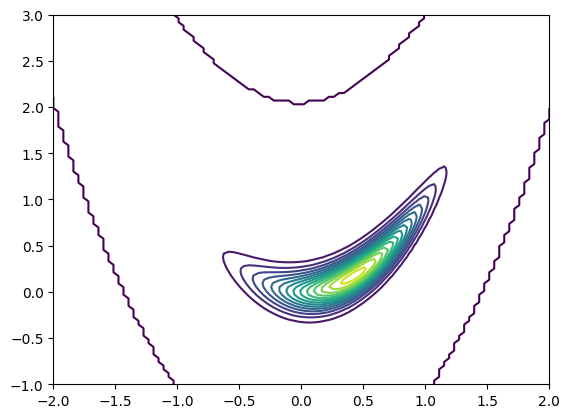

In [329]:
def post_dens(theta):
    z1, z2 = theta[:, 0], theta[:, 1]
    return (-(1-z1)**2) - (20*(z2-z1**2)**2) - (z1**2) - z2**2

x_grid, log_density_grid = eval_density_grid(post_dens)

z1_grid = jnp.linspace(-2, 2, 100)
z2_grid = jnp.linspace(-1, 3, 100)
Z1, Z2 = jnp.meshgrid(z1_grid, z2_grid)
ZZ = jnp.column_stack((Z1.ravel(), Z2.ravel()))
log_density_grid = post_dens(ZZ).reshape(100, 100)

plt.contour(Z1, Z2, jnp.exp(log_density_grid), levels=15)

### 5.2

In [330]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas

In [ ]:
def post_dens(theta):
    z1, z2 = theta[0], theta[1]
    return (-(1-z1)**2) - (20*(z2-z1**2)**2) - (z1**2) - z2**2

# specify number of parameters in the target distribution
num_params = 2
# specify the parameters of the MH algorithm
num_iterations = 10**4
warm_up = int(0.1*num_iterations)
tau = 1

# run sampler
thetas = metropolis(post_dens, num_params, tau, num_iterations, theta_init=jnp.array([0.0, 1.5]), seed=1)

Acceptance ratio: 0.09


In [332]:
x_line = jnp.linspace(0, num_iterations, num_iterations + 1)
x_line

Array([0.000e+00, 1.000e+00, 2.000e+00, ..., 9.998e+03, 9.999e+03,
       1.000e+04], dtype=float32)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


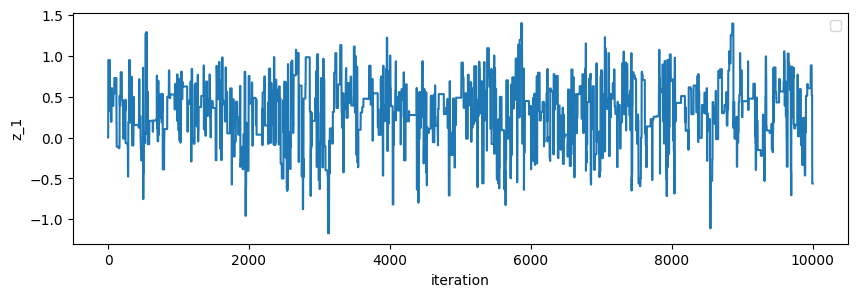

In [333]:
x_line = jnp.linspace(1, num_iterations, num_iterations + 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas[:, 0])
ax.set(xlabel='iteration', ylabel='z_1')
ax.legend();

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


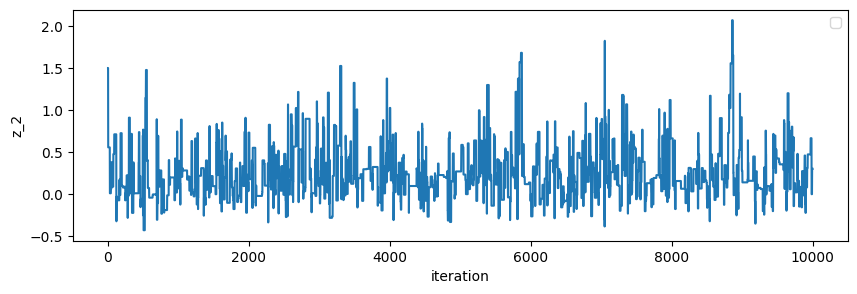

In [334]:
x_line = jnp.linspace(1, num_iterations, num_iterations + 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(x_line, thetas[:, 1])
ax.set(xlabel='iteration', ylabel='z_2')
ax.legend();

### 5.3

In [335]:
z_1s = thetas[:, 0]
z_2s = thetas[:, 1]

jnp.mean(jnp.sin(z_1s * z_2s))

Array(0.13746195, dtype=float32)

### 5.4

In [336]:
jnp.mean(z_1s > z_2s)

Array(0.7192281, dtype=float32)